---
title: PRISM Algorithm 2
authors: [gvarnavides]
date: 2026-08-10
---

In [1]:
%matplotlib widget
import py4DSTEM
import abtem
import ase

import ipywidgets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# abtem.config.set({"dask.lazy":False});

## Multislice

In [2]:
Si3N4_crystal = ase.Atoms(
    "Si6N8",
    scaled_positions=[
        (0.82495, 0.59387, 0.75),
        (0.23108, 0.82495, 0.25),
        (0.59387, 0.76892, 0.25),
        (0.40614, 0.23108, 0.75),
        (0.76892, 0.17505, 0.75),
        (0.17505, 0.40613, 0.25),
        
        (0.66667, 0.33334, 0.75),
        (0.33334, 0.66667, 0.25),
        (0.66986, 0.70066, 0.75),
        (0.96920, 0.66986, 0.25),
        (0.70066, 0.03081, 0.25),
        (0.29934, 0.96919, 0.75),
        (0.33015, 0.29934, 0.25),
        (0.03081, 0.33014, 0.75),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120],
    pbc=True
)

Si3N4_orthorhombic = abtem.orthogonalize_cell(Si3N4_crystal)
Si3N4_orthorhombic *= (3,2,17)

In [3]:
potential = abtem.Potential(
    Si3N4_orthorhombic,
    # sampling = 0.2,
    gpts = (128,144),
    slice_thickness = Si3N4_orthorhombic.cell[2,2]/32,
    parametrization = 'lobato',
    projection = 'finite',
).build(
).compute(
)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
s_matrix_1 = abtem.SMatrix(
    potential=potential,
    energy=300e3,
    semiangle_cutoff=20,
    downsample=None,
    interpolation=1,
).build(
).compute(
)


tasks:   0%|          | 0/12 [00:00<?, ?it/s]

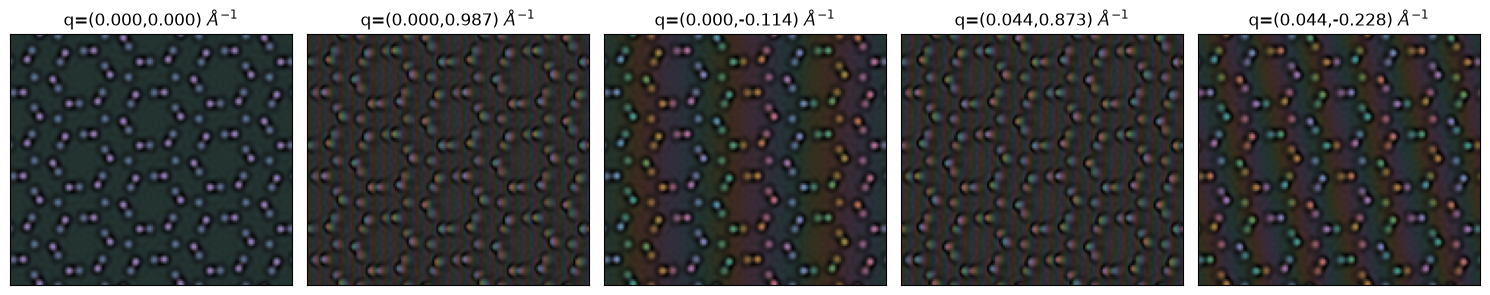

In [5]:
#| label: prism_multislice

delta = 26
arrays = s_matrix_1.waves[:5*delta:delta].array
wavevectors = s_matrix_1.waves[:5*delta:delta].ensemble_axes_metadata[0].values
titles = [f"q=({kx:.3f},{ky:.3f})"+r" $\AA^{-1}$" for kx,ky in wavevectors]

with plt.ioff():
    py4DSTEM.show_complex(
        arrays,
        title=titles,
        vmin=0,vmax=1,
        ticks=False,
        cbar=False,
        axsize=(3,3)
    )
plt.gcf()  

## Interpolation Factor

In [6]:
s_matrix_2 = abtem.SMatrix(
    potential=potential,
    energy=300e3,
    semiangle_cutoff=20,
    downsample=None,
    interpolation=2,
).build(
).compute(
)

s_matrix_3 = abtem.SMatrix(
    potential=potential,
    energy=300e3,
    semiangle_cutoff=20,
    downsample=None,
    interpolation=3,
).build(
).compute(
)

s_matrix_4 = abtem.SMatrix(
    potential=potential,
    energy=300e3,
    semiangle_cutoff=20,
    downsample=None,
    interpolation=4,
).build(
).compute(
)

s_matrix_6 = abtem.SMatrix(
    potential=potential,
    energy=300e3,
    semiangle_cutoff=20,
    downsample=None,
    interpolation=6,
).build(
).compute(
)

tasks:   0%|          | 0/6 [00:00<?, ?it/s]

The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.


tasks:   0%|          | 0/6 [00:00<?, ?it/s]

The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.


tasks:   0%|          | 0/6 [00:00<?, ?it/s]

The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.


tasks:   0%|          | 0/6 [00:00<?, ?it/s]

The interpolation factor does not exactly divide 'gpts', normalizationmay not be exactly preserved.


In [7]:
probe_arrays = [
    s.reduce(
        scan=abtem.CustomScan(np.array(potential.extent)/2),
        ctf=abtem.CTF(defocus=100),
        detectors=abtem.WavesDetector()
    ).array[0]
    for s in (s_matrix_1,s_matrix_2,s_matrix_3,s_matrix_4,s_matrix_6)
]

probe_fourier_arrays = [np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(arr))) for arr in probe_arrays]

probe_titles = [f"interpolation factor: {f}" for f in (1,2,3,4,6)]

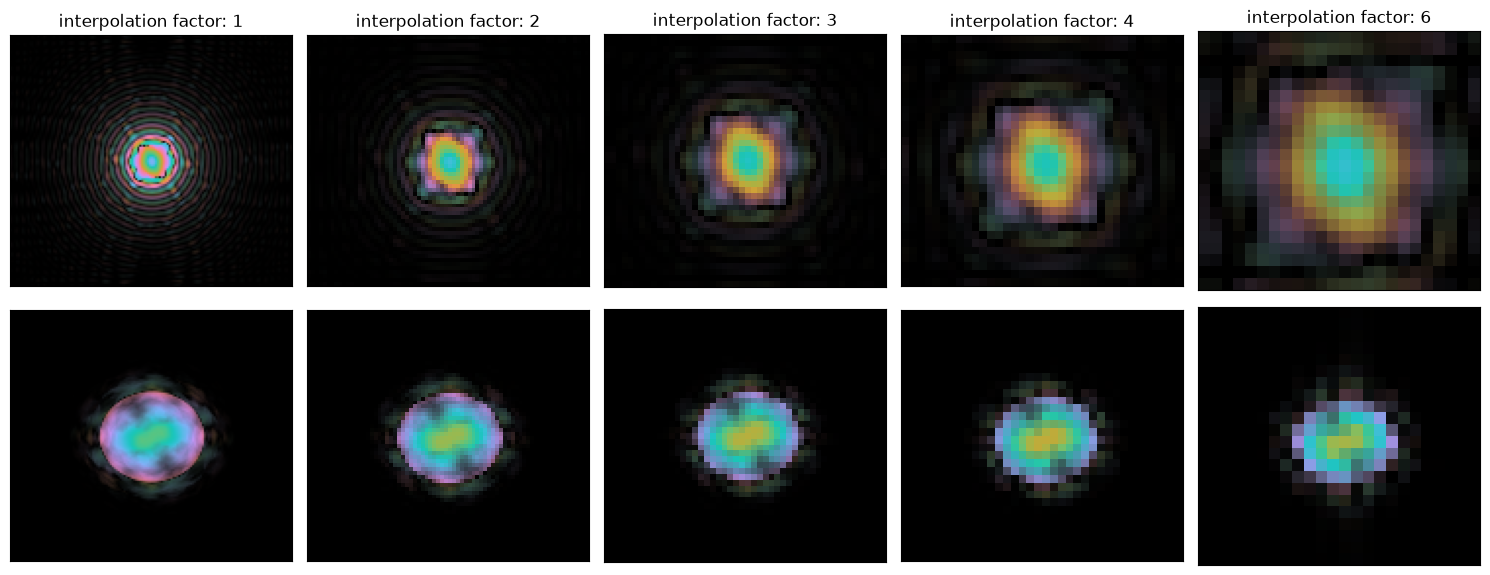

In [8]:
#| label: prism_interpolation_factor

with plt.ioff():
    py4DSTEM.show_complex(
        [
            probe_arrays,
            probe_fourier_arrays
        ],
        ticks=False,
        cbar=False,
        title=probe_titles,
        axsize=(3,3),
    )
plt.gcf()